In [1]:
## -- keras library --
try:
    import tensorflow as tf
except:
    !uv pip install tensorflow
    import tensorflow as tf

In [2]:
try:
    from scikeras.wrappers import KerasClassifier
except:
    !uv pip install scikeras
    from scikeras.wrappers import KerasClassifier

!pip show scikeras

Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 365ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 26ms
Installed 1 package in 5ms
 + scikeras==0.13.0
Name: scikeras
Version: 0.13.0
Summary: Scikit-Learn API wrapper for Keras.
Home-page: https://github.com/adriangb/scikeras
Author: Adrian Garcia Badaracco
Author-email: 1755071+adriangb@users.noreply.github.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: keras, scikit-learn
Required-by: 


In [3]:
!pip install ipywidgets
!pip install pygraphviz
!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.8 MB/s eta 0:00:00
Selecting previously unselected package libatk1.0-data.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ..

In [4]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [5]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from tqdm import tqdm
from time import time, sleep

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

import warnings
# warnings.filterwarnings("ignore", message="Setting the random state for TF")
tf.get_logger().setLevel('ERROR')
warnings.simplefilter('ignore')

In [6]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [8]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


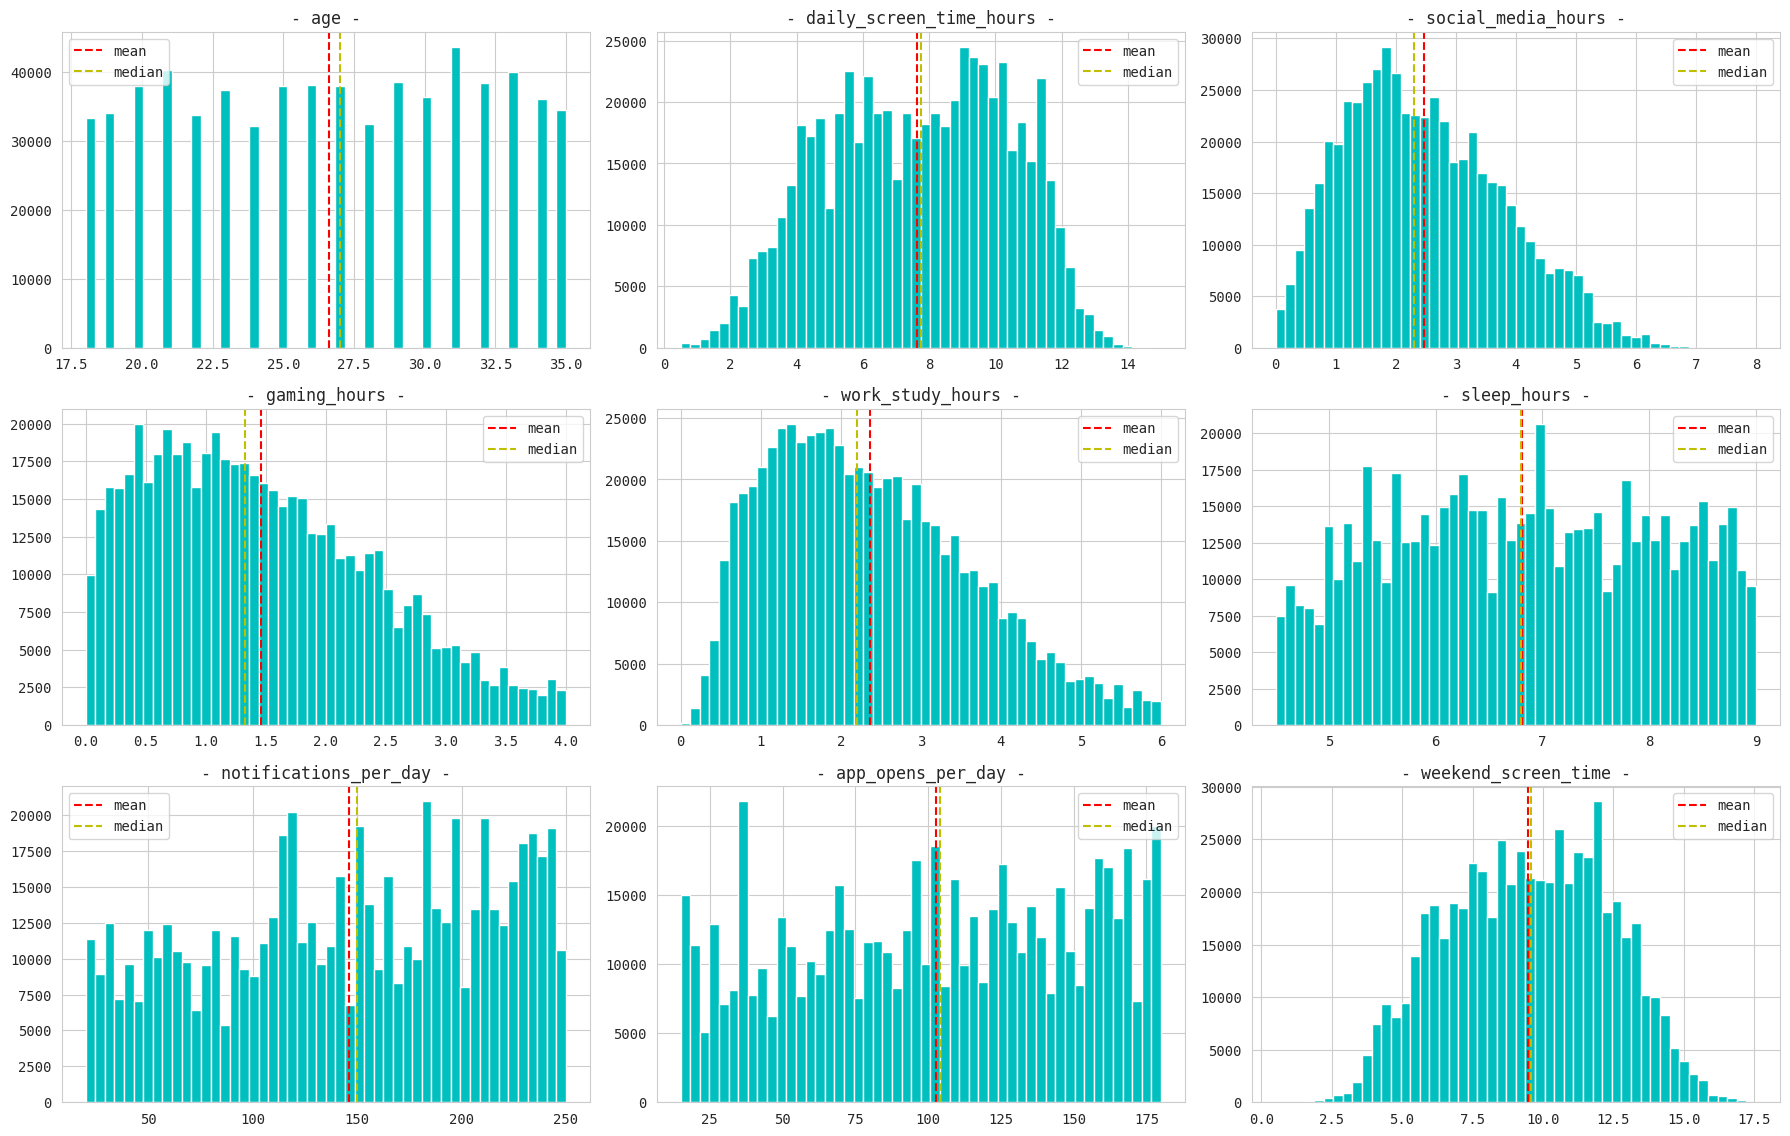

In [10]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f"- {col} -")
    plt.legend()

plt.tight_layout()
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [12]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [13]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print("- Helper Functions Ready -")

- Helper Functions Ready -


## FEATURE ENGINEERING

In [14]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [15]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [18]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    # num_to_cat = []
    # for col in num_features_:
    #     cat_name = f"{col}_cat"
    #     df[cat_name] = df[col].fillna('NaN').astype(str)
    #     num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols 


train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

# new_cats = [c for c in FE_COLS if c.endswith("_cat")]

# new_cats = ["missing_count"]
# new_cats.extend([
#     c for c in FE_COLS
#     if "_round" in c
#     or c.endswith("_cat")
#     or c.startswith("ci_")
# ])

# new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
# NUMS.extend(new_nums)

# display(train[new_cats+new_nums].head())

train[FE_COLS].nunique().sort_values()


ci_case                                3
gaming_hours_round0                    5
ci_n_missing                           5
sleep_hours_round0                     6
work_study_hours_round0                7
social_media_hours_round0              9
missing_count                         12
daily_screen_time_hours_round0        16
age_round1                            18
age_round0                            18
weekend_screen_time_round0            18
gaming_hours_round1                   41
sleep_hours_round1                    46
work_study_hours_round1               61
social_media_hours_round1             81
daily_screen_time_hours_round1       146
app_opens_per_day_round0             166
app_opens_per_day_round1             166
weekend_screen_time_round1           167
notifications_per_day_round0         231
notifications_per_day_round1         231
ci_daily_lb                         2222
total_breakdown_hours               3063
ci_missing_comp_ub                  4211
ci_interval_widt

In [19]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [20]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end="")
# for col in NUMS:
#     freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
#     n = f"{col}_FREQ"
#     print(n+", ", end="")
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype("float32")
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

# train[NUMS+FREQ_COLS]

In [21]:
## -- Cyclic encoding --
CYCLICS = []
cy_cols = [c for c in train.columns if c.endswith("_hours")]

for col in tqdm(cy_cols):
    for p in [12, 24]:
        n_s = f"{col}_sin_{p}"
        
        train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
        orig[n_s]  = np.sin(2 * np.pi * orig[col] / p).astype('float32')
        test[n_s]  = np.sin(2 * np.pi * test[col] / p).astype('float32')
        CYCLICS.append(n_s)

        # n_c = f"{col}_cos_{p}"
        # train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')
        # test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')
        # orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')
        # CYCLICS.append(n_c)



# NUMS.extend(CYCLICS)

print(f"Cylcic Features created: {len(CYCLICS)}")
print(train[CYCLICS].describe().T)

train[CYCLICS].head()

100%|██████████| 6/6 [00:00<00:00, 16.47it/s]


Cylcic Features created: 12
                                   count      mean       std       min  \
daily_screen_time_hours_sin_12  595515.0 -0.236168  0.669038 -1.000000   
daily_screen_time_hours_sin_24  595515.0  0.694852  0.308752 -0.707107   
social_media_hours_sin_12       557374.0  0.749730  0.248776 -0.866025   
social_media_hours_sin_24       557374.0  0.565418  0.249960  0.000000   
gaming_hours_sin_12             564548.0  0.605986  0.297661  0.000000   
gaming_hours_sin_24             564548.0  0.360581  0.215976  0.000000   
work_study_hours_sin_12         639851.0  0.751345  0.235980  0.000000   
work_study_hours_sin_24         639851.0  0.547345  0.242554  0.000000   
sleep_hours_sin_12              646889.0 -0.328998  0.522602 -1.000000   
sleep_hours_sin_24              646889.0  0.927656  0.080077  0.707107   
total_breakdown_hours_sin_12    691369.0  0.153326  0.713027 -1.000000   
total_breakdown_hours_sin_24    691369.0  0.795909  0.221083 -0.621148   

         

,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24
0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439
1,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063
2,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000
3,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945
4,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429


In [22]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [23]:
# INTER = []
# inter_cols = ["missing_count", "ci_n_missing", "ci_case"]

# for c1, c2 in tqdm(list(itertools.combinations(inter_cols+CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"TE_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [25]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [26]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [27]:
# ## -- Apply log transformation --

# log_features = []

# for col in tqdm(["social_media_hours", "gaming_hours", "work_study_hours"]):
#     log_col = f"_log_{col}"
#     train[log_col] = np.log1p(train[col])
#     test[log_col]  = np.log1p(test[col])
#     orig[log_col]  = np.log1p(orig[col])
#     log_features.append(log_col)

# NUMS.extend(log_features)

# # ## -- Absolute values --
# # for df in [train, test, orig]:
# #     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
# #     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# # abs_features = ['abs_lap_delta', 'abs_degrade']

# plt.figure(figsize=(18, 5))
# for i, col in enumerate(log_features): # +abs_features
#     plt.subplot(1, 3, i+1)
#     sns.histplot(train[col], bins=50)
#     # orig[col].plot.hist()
#     plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
#     plt.title(col)
#     plt.legend()

# plt.tight_layout()
# plt.show()

# train[log_features].describe().T

In [28]:
# train[f"age__cubed"] = train["age"]**3
# test[f"age__cubed"]  = test["age"]**3
# orig[f"age__cubed"]  = orig["age"]**3

# NUMS.append(f"age__cubed")

# NUMS

In [29]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

combined = pd.concat([train, test, orig])

combined[CATS] = combined[CATS].fillna("_empty_").astype(str)
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
CATS_2 = []
for c in tqdm(NUMS):
    n = f"cat_{c}"
    combined[n] = combined[c].factorize()[0]
    CATS_2.append(n)
# CATS.extend(CATS_2)
FEATURES.extend(CATS_2)
## ------------------------------------------------------------
# ## -- Factorize all CATS data --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")
print("Total Features:", len(FEATURES))

train

100%|██████████| 9/9 [00:00<00:00, 47.27it/s]


Label encoding complete!
Total Features: 68


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_empty_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_empty_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,-0.596225,0.313992,0.991445,0.751840,0.732543,0.399549,0.760406,0.418660,-0.780430,0.901455,-0.243615,0.992439,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.

In [30]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

train

Total Features: 68


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_empty_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_empty_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,-0.596225,0.313992,0.991445,0.751840,0.732543,0.399549,0.760406,0.418660,-0.780430,0.901455,-0.243615,0.992439,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.

In [31]:
## -- Ohe-Hot encode categories --
# OHE_CATS = CATS.copy()

combined = pd.get_dummies(
    pd.concat([train[FEATURES], test[FEATURES], orig[FEATURES]]),
    columns=CATS,
    dtype="float32",
)

train = pd.concat([combined.iloc[:len(train)], train[TARGET]], axis=1)
test  = combined.iloc[len(train):len(train)+len(test)]
orig  = pd.concat([combined.iloc[len(train)+len(test):], orig[TARGET]], axis=1)

print(f'One-Hot Encoding complete! Expanded Features: {combined.shape[1]}')
del combined

train

One-Hot Encoding complete! Expanded Features: 76


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,gender_Female,gender_Male,gender_Other,gender__empty_,stress_level_High,stress_level_Low,stress_level_Medium,stress_level__empty_,academic_work_impact_No,academic_work_impact_Yes,academic_work_impact__empty_,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,0,-1,0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,1,0,1,-1,1,1,1,1,-1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,2,1,-1,-1,-1,2,2,2,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,3,2,2,1,2,3,3,3,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,4,3,3,2,3,4,-1,-1,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732

In [32]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

# NEW_CATS = [c for c in FEATURES if c.endswith('_')]
# print('Total new Cats:', len(NEW_CATS))

# NEW_NUMS = [c for c in FEATURES if c.startswith('_')]
# print('Total new Nums:', len(NEW_NUMS))

train.head()

Total Features: 76


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,gender_Female,gender_Male,gender_Other,gender__empty_,stress_level_High,stress_level_Low,stress_level_Medium,stress_level__empty_,academic_work_impact_No,academic_work_impact_Yes,academic_work_impact__empty_,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,0,-1,0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,1,0,1,-1,1,1,1,1,-1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,2,1,-1,-1,-1,2,2,2,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,3,2,2,1,2,3,3,3,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,4,3,3,2,3,4,-1,-1,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


# ML TRAINING

In [33]:
def build_keras_model(shape, lr, units, act, drop):

    # 2. Create the Sequential model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        tf.keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(units[0], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(units[1], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(units[2], act), #use_bias=False,
        tf.keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- Output --
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    ## -- Compile model --
    model.compile(
        # optimizer=tf.keras.optimizers.RMSprop(learning_rate),
        optimizer=tf.keras.optimizers.Adam(lr), # , weight_decay=None
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model

print("⚙️ Keras model ready ⚙️")

⚙️ Keras model ready ⚙️


In [34]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace=None,
#     num_layers=3,
#     layer_units=128,
#     learning_rate=0.01,
#     dropout_rate=0.3,
#     l2_reg=0.0,
#     **kwargs
#     ):
#     # 1. Setup Inputs
#     dict_inputs = feature_space.get_inputs()

#     # 2. Build the MLP using Sequential for efficiency and readability
#     # We use the encoded features as the starting point
#     encoded_features = feature_space.get_encoded_features()

#     layers = []
#     kernel_reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0.0 else None

#     for i in range(num_layers):
#         # Calculate dimension d for Dense layer: halves with each layer, minimum of 32 units
#         d = max(32, layer_units // (2**i))
#         layers.append(tf.keras.layers.Dense(units=d, 'relu', kernel_regularizer=kernel_reg))
#         layers.append(tf.keras.layers.BatchNormalization())
#         layers.append(tf.keras.layers.Dropout(dropout_rate))
#         # Increase dropout as layers get deeper/smaller -> dropout_rate+(i * 0.05)

#     # Final output layer
#     layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

#     # 3. Create the Sequential model for the "head"
#     mlp_head = tf.keras.Sequential(layers)

#     # 4. Connect everything
#     outputs = mlp_head(encoded_features)
#     train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

#     # 5. Compile
#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='binary_crossentropy',
#         metrics=[tf.keras.metrics.AUC(name='auc')]
#     )

#     infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

#     return train_model, infer_model

# print('⚙️ SEQUENTIAL MODEL ⚙️')


In [35]:
## -- See all features with NaN
train[train.columns[train[train.columns].isna().any()]]

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,-0.596225,0.313992,0.991445,0.751840,0.732543,0.399549,0.760406,0.418660,-0.780430,0.901455
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.972370,0.785317,0.827081,0.467930,0.449319,0.230899,0.156434,0.078459,-0.304033,0.988095
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.881303,0.513541,-0.083678,0.999123
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,-0.114937,0.057564,0.935444,0.822641,0.120137,0.060177,0.649448,0.346117,0.243615,0.992439


In [36]:
## -- Define TranerCV --

class TrainerCV:
    def __init__(
        self,
        model_builder, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kfold,
        learning_rate: float=0.01,
        layer_units: list=[256, 128, 64],
        drop_rate: float=0.2,
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        eval_metric: str='auc',
        use_original: bool=False,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features.copy()
        self.target = target
        self.kfold = kfold
        self.learning_rate = learning_rate
        self.units = layer_units
        self.drop_rate = drop_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.eval_metric = eval_metric
        self.use_original = use_original

        self.result = None

        # Storage
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
        # This helper can be extended if you want to apply masks or augmentation.
        return X, y

    def fit(self):
        print(f"\n===== Starting CV: {self.model_name} | =====")
        t0 = time()

        self.oof_preds  = np.zeros(len(self.train_df))
        self.test_preds = np.zeros(len(self.test_df))
        self.oof_scores = []
        self.fold_histories = []

        # Handle optional original table aggregations securely if flags enable them
        if self.use_original and "orig_TE_data_propagate" in globals():
            aggs_ = ["mean", "std"]
            X_tr, orig_cols = orig_TE_data_propagate(
                orig, self.train_df, target=self.target, features=BASE, aggs=aggs_, fill_nan=True
            )
            x_test, _ = orig_TE_data_propagate(
                orig, self.test_df, target=self.target, features=BASE, aggs=aggs_, fill_nan=True
            )
            self.features.extend(orig_cols)
            X = X_tr[self.features].copy()
            X_ts = x_test[self.features].copy()
            y = X_tr[self.target].astype("int8")
        else:
            X = self.train_df[self.features].copy()
            X_ts = self.test_df[self.features].copy()
            y = self.train_df[self.target].astype("int8")

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n+++++ Fold {idx}/{self.kfold.n_splits}", end=" | ")

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = X_ts.copy()

            # if self.use_orig:
            #     X_train = pd.concat([X_train, orig[features]]).fillna('unknown').reset_index(drop=True).copy()
            #     y_train = pd.concat([y_train, orig[target]]).reset_index(drop=True).copy()
            #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

            # ## -- TE Opt1. -> Using CUSTOM -- + ROUNDS
            # te_enc1 = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            # X_train = te_enc1.fit_transform(X_train, y_train)
            # X_valid = te_enc1.transform(X_valid)
            # X_test  = te_enc1.transform(X_test)
    
            ## -- TE Opt1. -> Using CUSTOM --
            te_enc2 = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = te_enc2.fit_transform(X_train, y_train)
            X_valid = te_enc2.transform(X_valid)
            X_test  = te_enc2.transform(X_test)
            
            imputer = SimpleImputer().set_output(transform="pandas")
            X_train = imputer.fit_transform(X_train, y_train)
            X_valid = imputer.transform(X_valid)
            X_test  = imputer.transform(X_test)

            non_binary_cols = [c for c in X_train.columns if X_train[c].nunique() > 2]

            # ---- Scaling ----  
            scaler = StandardScaler().set_output(transform="pandas")
            X_train = scaler.fit_transform(X_train, y_train)
            X_valid = scaler.transform(X_valid)
            X_test  = scaler.transform(X_test)
            
            # impute_num_cols = X_train.columns[X_train[X_train.columns].isna().any()].tolist()
            # if impute_num_cols:
            #     imputer = SimpleImputer()
            #     X_train.loc[:, impute_num_cols] = imputer.fit_transform(X_train[impute_num_cols])
            #     X_valid.loc[:, impute_num_cols] = imputer.transform(X_valid[impute_num_cols])
            #     X_test.loc[:, impute_num_cols]  = imputer.transform(X_test[impute_num_cols])
            
            # #     # estimator = HistGradientBoostingRegressor(random_state=0)
            # imputer = IterativeImputer(tol=1e-3, n_nearest_features=10, random_state=0)
            # X_train = imputer.fit_transform(X_train, y_train)
            # X_valid = imputer.transform(X_valid)
            # X_test  = imputer.transform(X_test)

            # -- Callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    patience=self.patience,
                    mode="max" if self.eval_metric == "auc" else "min",
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    mode="max" if self.eval_metric == "auc" else "min",
                    save_best_only=True,
                    # verbose=1
                ),
                # tf.keras.callbacks.ModelCheckpoint( # -> save weights
                #     filepath=f"{CHECKPOINT}best_model.weights.h5",
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     save_best_only=True,
                #     save_weights_only=True,
                # ),
            ]

            print(f"shape: {X_train.shape} +++++")
            if idx == 1:
                display(X_train.head())

            # -- Build model --
            print(f"🟢 Training Model Graph...")
            # with strategy.scope():
            keras_clf = KerasClassifier(
                self.model_builder,
                model__shape=X_train.shape[1:],
                model__lr=self.learning_rate,
                model__units=self.units,
                model__act=self.activation,
                model__drop=self.drop_rate,
                # ---------------------------------------------------------
                # # optimizer=tf.keras.optimizers.RMSprop(self.learning_rate),
                # optimizer=tf.keras.optimizers.Adam(self.learning_rate), # , weight_decay=None
                # loss="binary_crossentropy",
                # metrics=[tf.keras.metrics.AUC(name=self.eval_metric)],
                # ---------------------------------------------------------
                epochs=self.epochs,
                batch_size=GLOBAL_BATCH_SIZE,
                # validation_batch_size=10000,
                # fit__batch_size=GLOBAL_BATCH_SIZE,
                # predict__batch_size=10000,
                random_state=CFG['SEED'],
                callbacks=callbacks,
                run_eagerly=False,
                shuffle=True,
                verbose=0,
                # class_weight=get_weights(y_train, y_train),
            )
                
            keras_clf.fit(X_train, y_train, validation_data=(X_valid, y_valid))
            # sample_weight=get_weights(y_train, y_train)

            self.fold_histories.append(keras_clf.history_)

            ## -- Make predictions --
            self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)[:, 1]
            fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            
            self.test_preds += keras_clf.predict_proba(X_test)[:, 1] / self.kfold.n_splits

            print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_auc:.6f}{CFG['RESET']}")

        # Print metrics
        print("\n==================================================")
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name}")
        print("==================================================")
        for i, s in enumerate(self.oof_scores, 1):
            print(f" • Fold {i} AUC: {s:.6f}")

        oof_AUC = np.round(roc_auc_score(y, self.oof_preds), 6)
        avg_AUC = np.round(np.mean(self.oof_scores), 6)
        std_AUC = np.round(np.std(self.oof_scores), 6)

        print("-------------------------------------------------|")
        print(f"Overall score: {oof_AUC}")
        print(f"Average score: {avg_AUC} ± {std_AUC}")
        print("-------------------------------------------------|")
        print(f"{(time()-t0)/60:.2f} mins\n")

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_AUC,
            'oof_score': oof_AUC,
            'val_data': [X_valid, y_valid],
            'history': self.fold_histories,
        }

print("⚙️ Keras trainer ready ⚙️")

⚙️ Keras trainer ready ⚙️


In [37]:
all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,gender_Female,gender_Male,gender_Other,gender__empty_,stress_level_High,stress_level_Low,stress_level_Medium,stress_level__empty_,academic_work_impact_No,academic_work_impact_Yes,academic_work_impact__empty_,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,0,-1,0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,1,0,1,-1,1,1,1,1,-1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,2,1,-1,-1,-1,2,2,2,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,3,2,2,1,2,3,3,3,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,4,3,3,2,3,4,-1,-1,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732

In [38]:
%%time

CHECKPOINT = "checkpoints/"
shutil.rmtree(CHECKPOINT, ignore_errors=True)
os.makedirs(CHECKPOINT, exist_ok=True)

LR          = 0.002
EPOCHS      = 250
PATIENCE    = 10
BATCH_SIZE  = 128
DROP_RATE   = 0.1
LAYER_UNITS = [512, 256, 64]

VERS = "sciKeras94_" #+ str(LAYER_UNITS)

trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=VERS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    learning_rate=LR,
    layer_units=LAYER_UNITS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    drop_rate=DROP_RATE,
    activation="selu",
    eval_metric="auc",
    use_original=True,
)

result = trainer.fit()


===== Starting CV: sciKeras94_ | =====


Original augment complete!: 100%|██████████| 9/9 [00:02<00:00,  4.30it/s]
2026-08-28 07:47:50.387754: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


⚙️ Number of devices: 1

+++++ Fold 1/5 | shape: (553095, 94) +++++


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,gender_Female,gender_Male,gender_Other,gender__empty_,stress_level_High,stress_level_Low,stress_level_Medium,stress_level__empty_,academic_work_impact_No,academic_work_impact_Yes,academic_work_impact__empty_,oTE_age_mean,oTE_age_std,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_std,oTE_social_media_hours_mean,oTE_social_media_hours_std,oTE_gaming_hours_mean,oTE_gaming_hours_std,oTE_work_study_hours_mean,oTE_work_study_hours_std,oTE_sleep_hours_mean,oTE_sleep_hours_std,oTE_notifications_per_day_mean,oTE_notifications_per_day_std,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_std,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_std,TE_cat_age_mean,TE_cat_daily_screen_time_hours_mean,TE_cat_social_media_hours_mean,TE_cat_gaming_hours_mean,TE_cat_work_study_hours_mean,TE_cat_sleep_hours_mean,TE_cat_notifications_per_day_mean,TE_cat_app_opens_per_day_mean,TE_cat_weekend_screen_time_mean
0,-0.519007,-1.054753e-15,-0.543985,1.550300e-01,-2.109252e-01,0.549294,-0.380768,-1.429220e+00,-0.324599,-0.519007,-0.519007,3.491280e-16,1.054470e-15,-3.909766e-01,-0.569261,0.614644,0.166812,-3.043754e-01,-2.194309e-01,0.152170,0.581549,-0.380768,-0.380768,-1.429220e+00,-1.429220e+00,-1.857941e-01,-0.335998,0.062812,0.000000,8.734190e-16,-4.521097e-16,-2.233448e-16,1.578801e-15,1.033219e-15,-3.161174e-16,4.303121e-16,-1.694839e+00,-5.165435e-16,-5.165435e-16,-5.165435e-16,0.000000,0.744789,0.481429,-0.185007,-1.341019e-16,0.000000,3.051586e-01,-4.670490e-01,4.967951e-01,0.224391,6.264733e-01,-0.095562,-0.718524,0.002046,0.126872,0.887936,-0.686660,1.444002,-0.675777,-0.209223,-0.684458,-0.656005,1.526530,-0.294552,1.088394,-0.957272,-0.261642,1.930238,-0.038838,-0.071707,-0.782247,-0.305207,0.777985,-0.069700,0.563716,0.320308,0.282491,1.524169,-0.606856,-0.186917,0.437543,2.073334,-0.263769,-0.627726,1.311559,1.759101,0.008031,-0.180252,-0.475907,0.310502,0.624413,-0.875458,1.336668,-0.025491
1,-1.510589,-6.618275e-01,-1.178477,-2.629844e-16,5.489729e-01,1.185910,-1.115410,-1.849529e+00,0.000000,-1.510589,-1.510589,-6.455735e-01,-6.496784e-01,-1.213885e+00,-1.161366,0.000000,0.000000,5.072991e-01,5.236821e-01,0.967879,1.167195,-1.115410,-1.115410,-1.849529e+00,-1.849529e+00,6.772939e-16,0.000000,-0.512625,-1.275241,8.734190e-16,1.541779e+00,-1.290196e-01,-1.026924e+00,1.033219e-15,-1.138913e+00,-6.206456e-01,1.915130e-15,-1.819954e+00,-1.819954e+00,-1.819954e+00,0.000000,2.020004,0.481429,0.531605,4.057021e-01,1.064263,-9.584091e-01,-1.277804e+00,-4.126731e-16,0.000000,1.095704e+00,0.709465,-1.164903,-1.186350,0.958011,0.379615,1.456324,-0.692520,-0.675777,-0.209223,-0.684458,-0.656005,1.526530,-0.294552,1.088394,-0.957272,-0.261642,0.212718,0.191254,-1.445036,1.267362,-0.390328,0.768585,0.007040,-1.978175,-0.587231,0.671836,-1.216388,0.758943,-0.423291,0.488704,-1.767077,0.660164,-0.06

🟢 Training Model Graph...


...

 • Fold 3 AUC: 0.966527

+++++ Fold 4/5 | shape: (553095, 94) +++++
🟢 Training Model Graph...


2026-08-28 08:31:09.460801: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-28 08:31:52.655428: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

 • Fold 4 AUC: 0.966689

+++++ Fold 5/5 | shape: (553096, 94) +++++
🟢 Training Model Graph...


2026-08-28 08:44:03.786895: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-28 08:44:47.824452: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

 • Fold 5 AUC: 0.965807

5-FOLD CV: sciKeras94_
 • Fold 1 AUC: 0.965273
 • Fold 2 AUC: 0.966423
 • Fold 3 AUC: 0.966527
 • Fold 4 AUC: 0.966689
 • Fold 5 AUC: 0.965807
-------------------------------------------------|
Overall score: 0.966053
Average score: 0.966144 ± 0.000528
-------------------------------------------------|
71.35 mins

CPU times: user 2h 35min 52s, sys: 11min 55s, total: 2h 47min 48s
Wall time: 1h 11min 21s


In [39]:
# orig_te(mean, std) + sin(12, 24) + TE(CATS_2) + FE_COLS

# ==================================================
# 5-FOLD CV: sciKeras_[512, 256, 64] | (165928, 94)
# ==================================================
#  • Fold 1 AUC: 0.963996
#  • Fold 2 AUC: 0.964165
#  • Fold 3 AUC: 0.963570
#  • Fold 4 AUC: 0.964821
#  • Fold 5 AUC: 0.962845
# -------------------------------------------------|
# Overall score: 0.963708
# Average score: 0.963879 ± 0.000655
# -------------------------------------------------|
# 20.33 mins

result['oof_score'].item(), result['avg_score'].item()

(0.966053, 0.966144)

In [40]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_16          │ (None, 94)             │           376 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │        48,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,853 (2.28 MB)

 Trainable params: 198,333 (774.74 KB)

 Non-trainable params: 1,852 (7.23 KB)

 Optimizer params: 396,668 (1.51 MB)

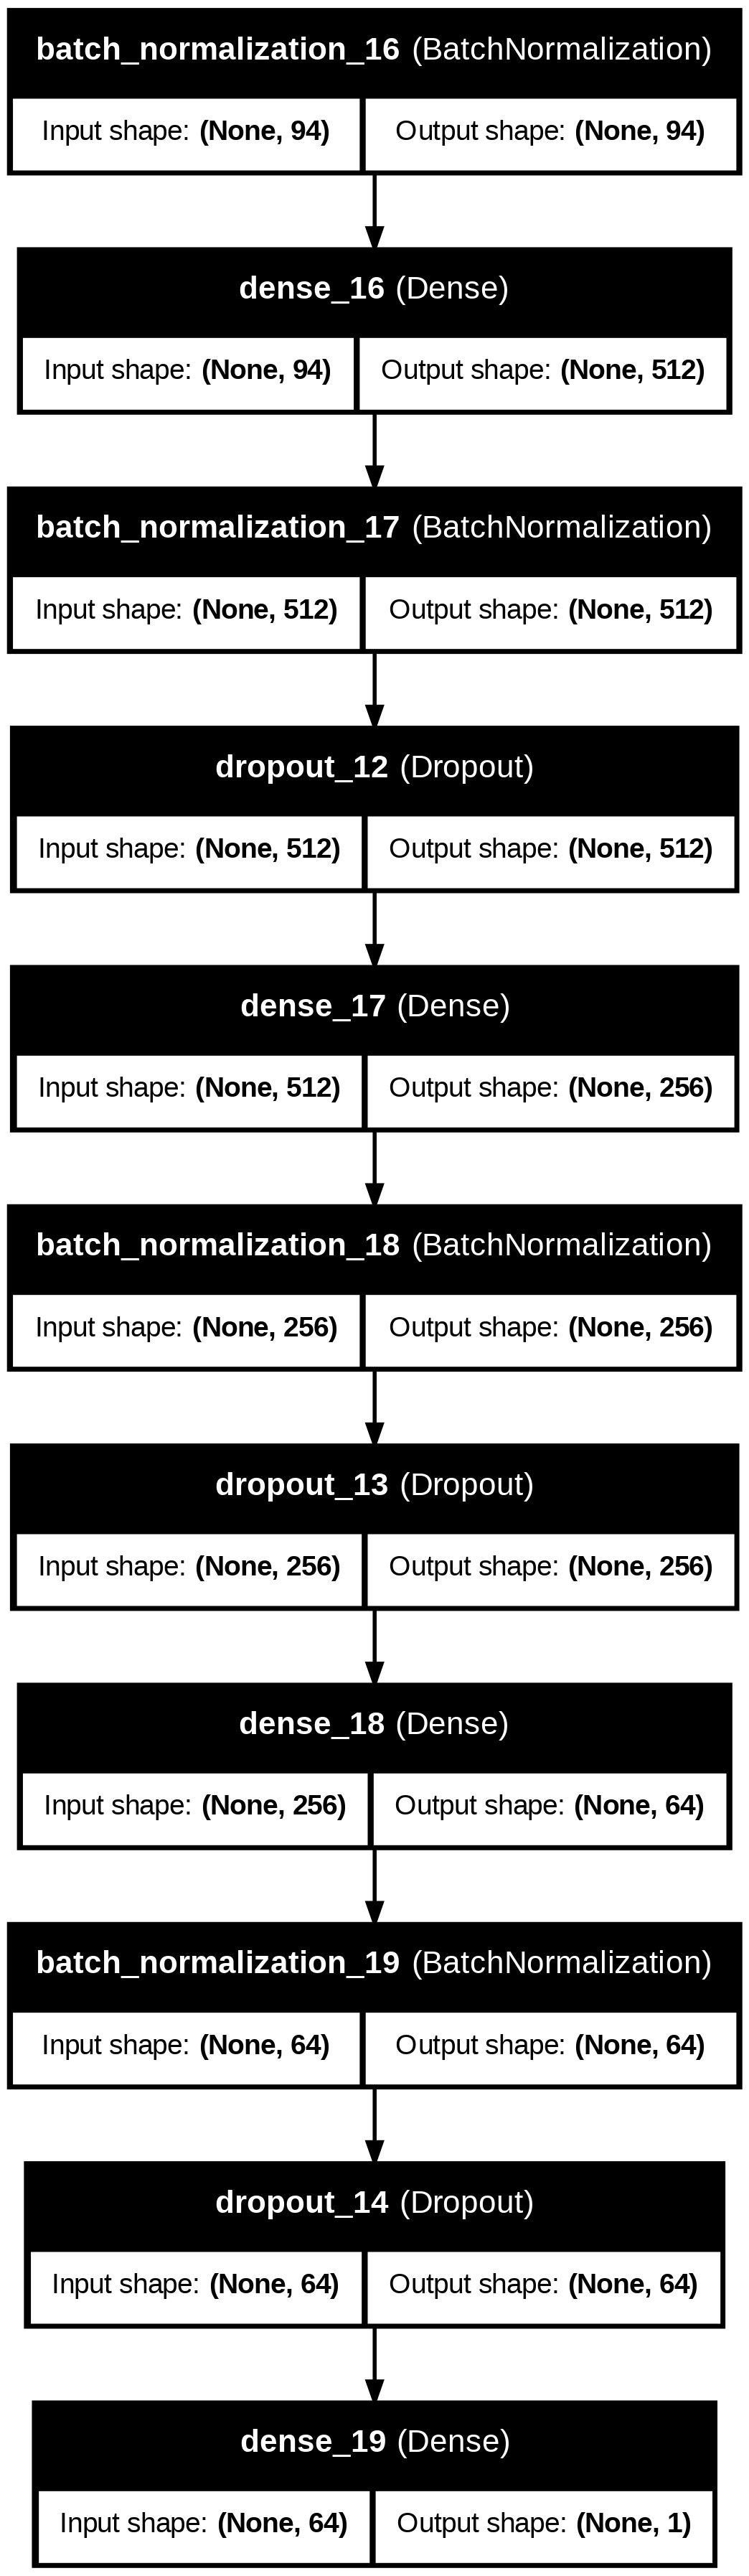

In [41]:
tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [42]:
def plot_results(history):
    for i in range(len(history)):
        loss_results = pd.DataFrame({'loss': history[i]['loss'], 'val_loss': history[i]['val_loss']})
        auc_results  = pd.DataFrame({'auc': history[i]['a_u_c'], 'val_auc': history[i]['val_auc']})
    
        plt.figure(figsize=(18, 6))
        marker = 'o'
    
        ## -- PLOT 1: LOSS --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['loss'], label='train', marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['val_loss'], label='valid', marker=marker)
        plt.title('LOSS', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')
    
        ## -- PLOT 2: ACCURACY --
        plt.subplot(122)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['auc'], label='train', marker=marker)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['val_auc'], label='valid', marker=marker)
        plt.title('AUC', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')

        stat_ = f"fold_score: {result['fold_score'][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color='y')
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        print()

print('Plot function ready')

Plot function ready


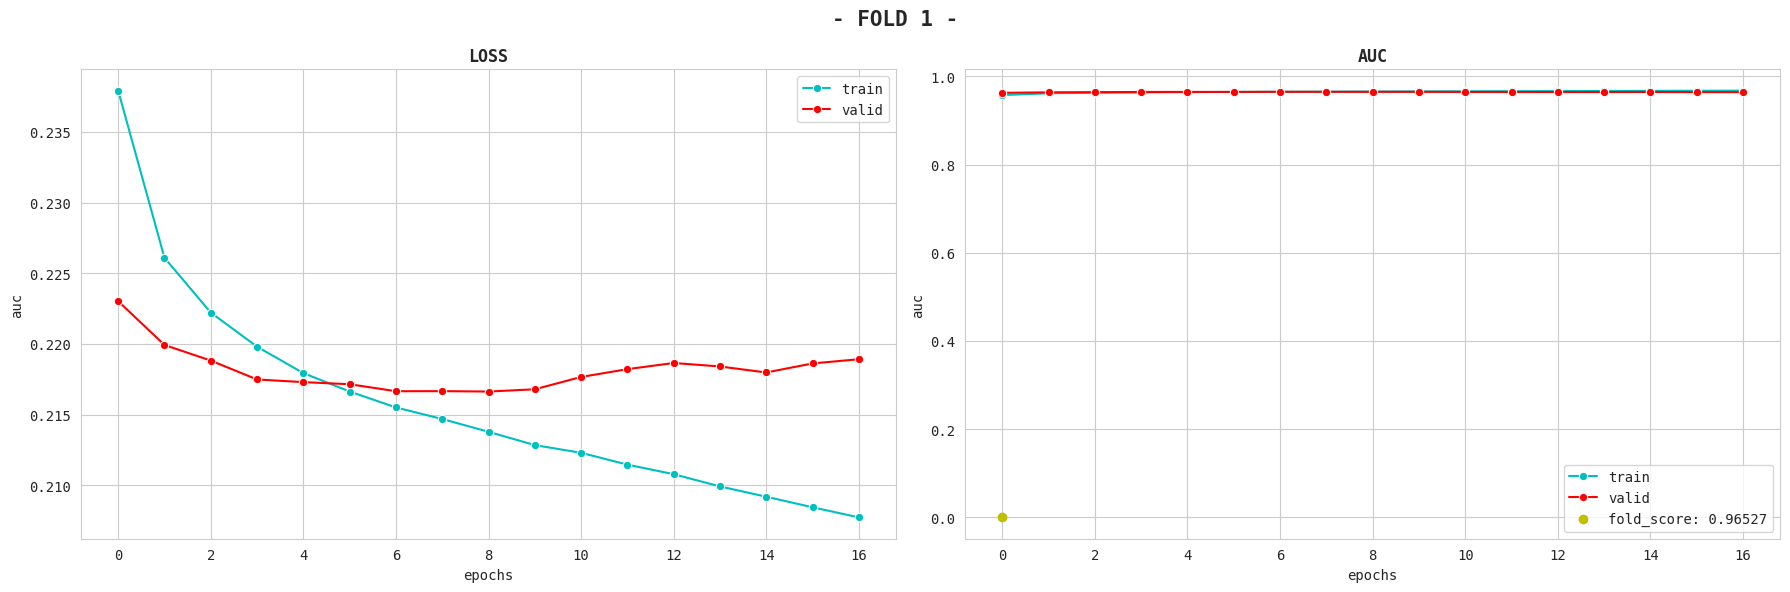

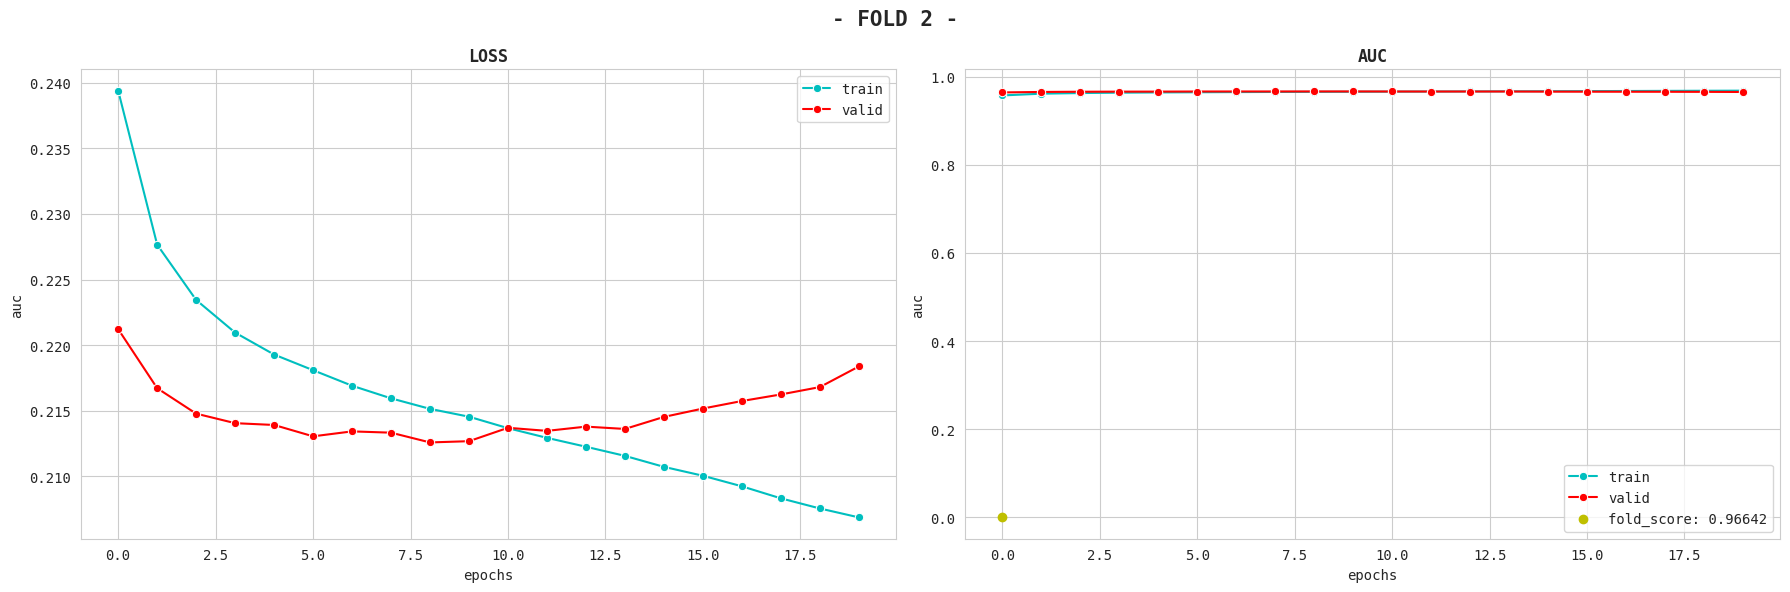

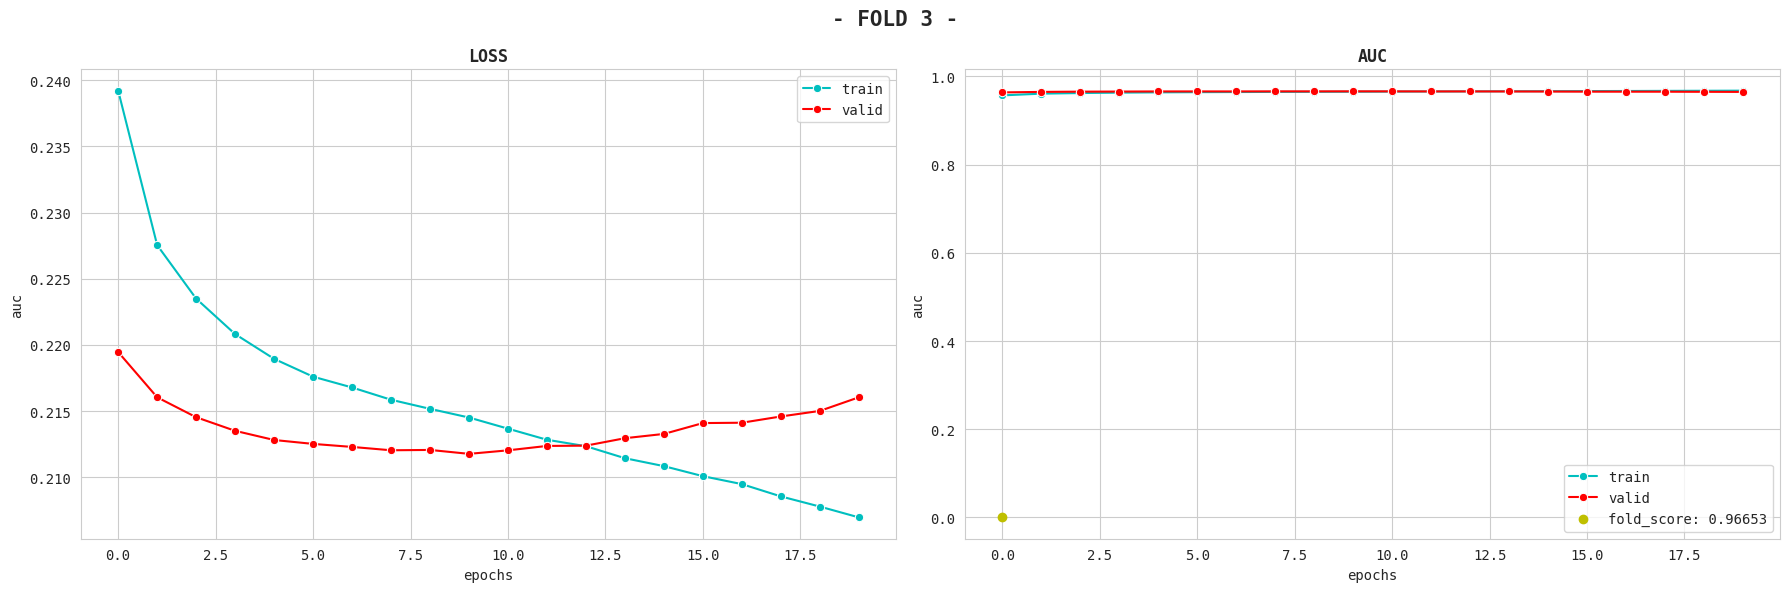

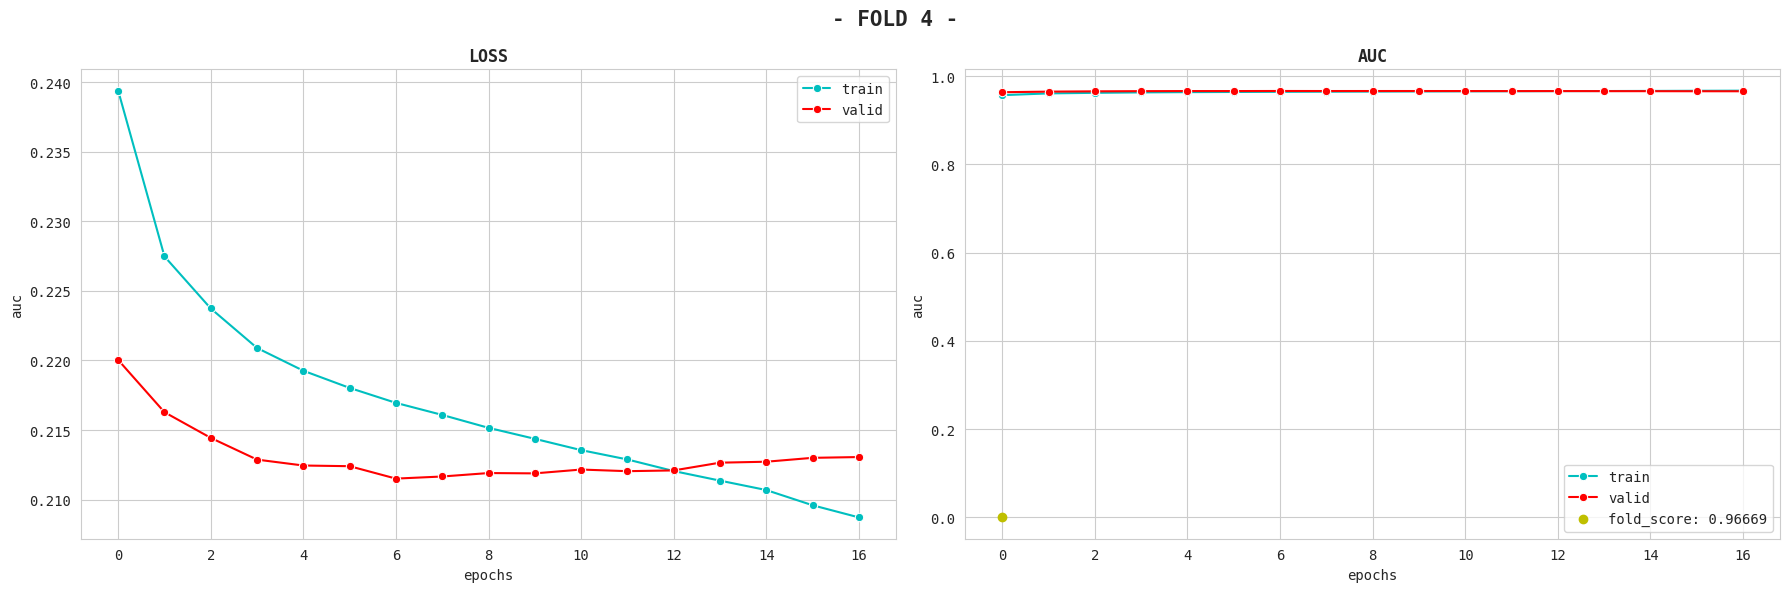

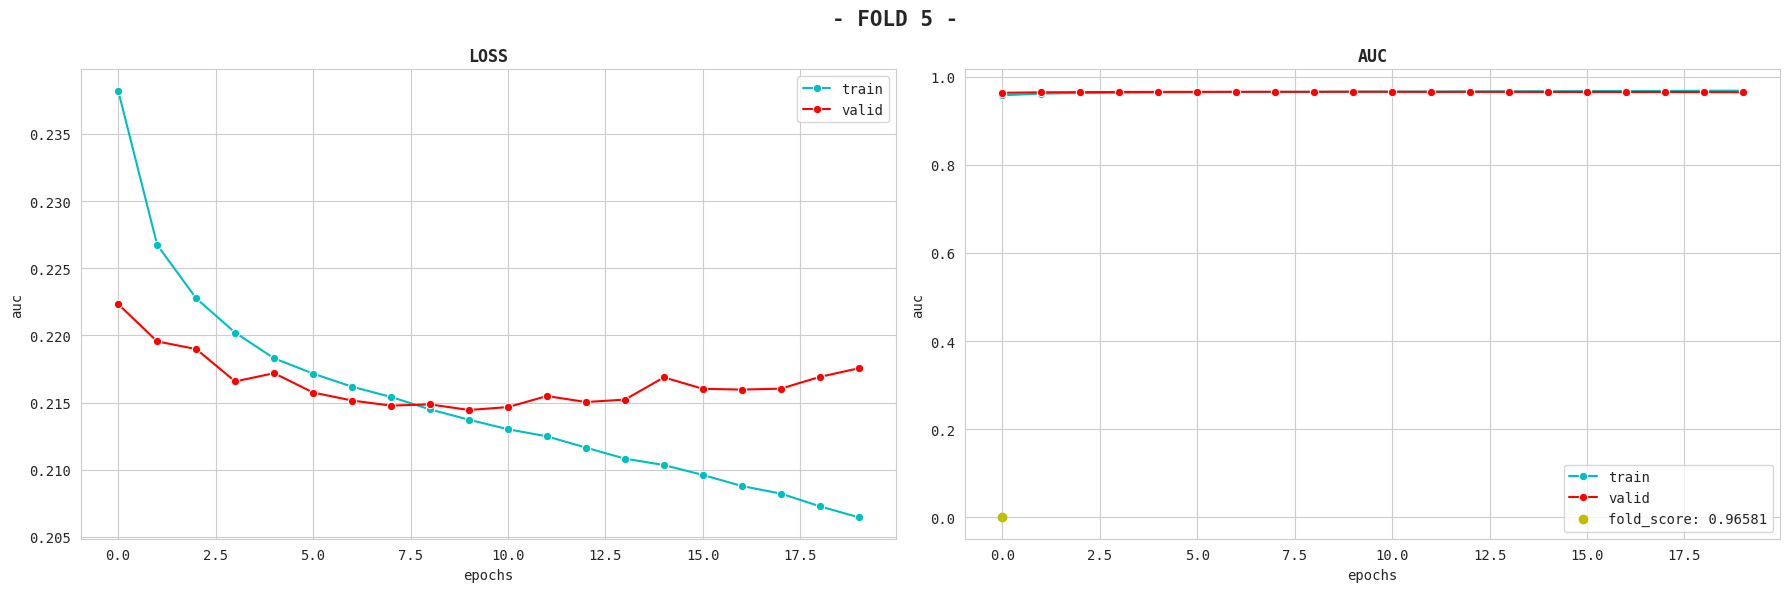

In [43]:
plot_results(result['history'])

Submission saved as: 'submit_sciKeras94_966053.csv'


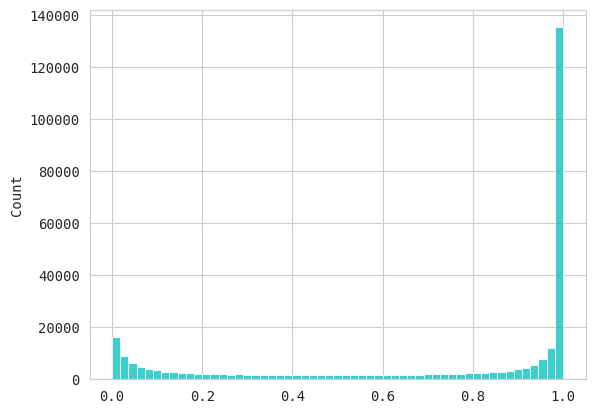

,id,addicted_label
0,691369,0.999337
1,691370,0.961254
2,691371,0.747441
3,691372,0.994028
4,691373,0.997896
...,...,...
296297,987666,0.999930
296298,987667,0.794441
296299,987668,0.167692
296300,987669,0.830241


In [44]:
n = VERS + str(result["oof_score"]).split('.')[1]

np.save(f"oof_{n}.npy", result["oof_preds"])
np.save(f"test_{n}.npy", result["test_preds"])

submit[TARGET] = result["test_preds"].ravel()
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Submission saved as: 'submit_{n}.csv'")

sns.histplot(submit[TARGET].values)
plt.show()

submit

In [45]:
# ## -- PLOTTING RESULTS --
# histories = result['history']

# for i, data in tqdm(enumerate(histories), total=len(histories)):
#     loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
#     auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
#     plt.figure(figsize=(16, 5))
#     marker = 'o'

#     ## -- PLOT LOSS --
#     plt.subplot(121)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
#     plt.title('LOSS', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')

#     ## -- PLOT AUC --
#     plt.subplot(122)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
#     plt.title('ROC-AUC', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('AUC')

#     stat_ = f"fold_auc: {result['fold_score'][i]:.5f}"
#     plt.scatter(x=0, y=0, label=stat_, color='y')

#     plt.suptitle(f"FOLD {i+1}", fontsize=16, fontweight='semibold')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()
#     print()